In [38]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import ai

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Canine Data EDA

## Canine Data Load

In [40]:
import os

dataset_path = '/content/drive/MyDrive/210 Capstone/datasets'

if os.path.exists(dataset_path):
    print(f"Files in '{dataset_path}' starting with 'Talk':")
    found_files = [f for f in os.listdir(dataset_path) if f.startswith('Talk')]
    if found_files:
        for f in found_files:
            print(f)
    else:
        print("No files found starting with 'Talk'.")
else:
    print(f"Directory '{dataset_path}' not found. Please ensure Google Drive is mounted and the path is correct.")

Files in '/content/drive/MyDrive/210 Capstone/datasets' starting with 'Talk':
TalkFile_버찌버찌_glucose_canine1.csv
TalkFile_빵진_glucose_canine2.csv
TalkFile_사랑이김_glucose_canine3.csv
TalkFile_연주송_glucose_canine4.csv
TalkFile_지혜김_glucose_canine5.csv
TalkFile_현수김_glucose_canine6.csv


In [41]:
dfs = []

for filename in found_files:
    full_file_path = os.path.join(dataset_path, filename)

    # Extract identifier to be 'canine1', 'canine2', etc.
    identifier = filename.split('_glucose_')[1].split('.')[0]

    # Read the file into a DataFrame
    df = pd.read_csv(full_file_path)

    # Add a new column 'file_identifier'
    df['file_identifier'] = identifier

    # Append the processed DataFrame to the list
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

print(f"Shape of the combined DataFrame: {combined_df.shape}")
print("First 5 rows of the combined DataFrame:")
print(combined_df.head())

Shape of the combined DataFrame: (38760, 7)
First 5 rows of the combined DataFrame:
                Device                         Serial Number Device Timestamp  \
0  FreeStyle LibreLink  a2e73825-5603-4370-9edc-6941970d3b10    12/2/25 11:50   
1  FreeStyle LibreLink  a2e73825-5603-4370-9edc-6941970d3b10    12/2/25 12:05   
2  FreeStyle LibreLink  a2e73825-5603-4370-9edc-6941970d3b10    12/2/25 12:20   
3  FreeStyle LibreLink  a2e73825-5603-4370-9edc-6941970d3b10    12/2/25 12:35   
4  FreeStyle LibreLink  a2e73825-5603-4370-9edc-6941970d3b10    12/2/25 12:50   

   Record Type  Historic Glucose mg/dL  Scan Glucose mg/dL file_identifier  
0            0                   260.0                 NaN         canine1  
1            0                   281.0                 NaN         canine1  
2            0                   296.0                 NaN         canine1  
3            0                   287.0                 NaN         canine1  
4            0                   285.0      

In [42]:
glucose_counts = combined_df.groupby('Record Type')[['Historic Glucose mg/dL', 'Scan Glucose mg/dL']].count()
display(glucose_counts)

,Historic Glucose mg/dL,Scan Glucose mg/dL
Record Type,,
0,23770,0
1,0,9126
5,0,0
6,0,0


In [43]:
combined_df['glucose'] = combined_df['Historic Glucose mg/dL'].fillna(combined_df['Scan Glucose mg/dL'])

# # Keep only rows where Record Type is 0
# combined_df = combined_df[combined_df['Record Type'] == 0]

# Keep only rows where Record Type is 0 or 1
combined_df = combined_df[combined_df['Record Type'].isin ([0,1])]

# Format Columns and Create canine_df
combined_df = combined_df[['file_identifier', 'Device Timestamp', 'glucose']]
combined_df = combined_df.rename(columns={'Device Timestamp': 'timestamp'})
combined_df.loc[:, 'timestamp'] = pd.to_datetime(combined_df['timestamp'], format='%m/%d/%y %H:%M')
combined_df['hypoglycemia']  = combined_df['glucose'] < 65
combined_df['hyperglycemia'] = combined_df['glucose'] > 250

canine_df = combined_df
display(canine_df.head())
print(f"Shape of canine_df: {canine_df.shape}")

,file_identifier,timestamp,glucose,hypoglycemia,hyperglycemia
0,canine1,2025-12-02 11:50:00,260.0,False,True
1,canine1,2025-12-02 12:05:00,281.0,False,True
2,canine1,2025-12-02 12:20:00,296.0,False,True
3,canine1,2025-12-02 12:35:00,287.0,False,True
4,canine1,2025-12-02 12:50:00,285.0,False,True


Shape of canine_df: (32896, 5)


## Analyze Hypoglycemia and Hyperglycemia Events

Quantify the frequency and duration of hypoglycemia (glucose < 65) and hyperglycemia (glucose > 250) events for each `file_identifier`.



In [44]:
def categorize_glucose(glucose):
    if glucose < 65:
        return 'Hypoglycemia'
    elif glucose > 250:
        return 'Hyperglycemia'
    else:
        return 'Normal'

canine_df['glucose_category'] = canine_df['glucose'].apply(categorize_glucose)

print("First 10 rows with new 'glucose_category' column:")
display(canine_df.head(10))

First 10 rows with new 'glucose_category' column:


,file_identifier,timestamp,glucose,hypoglycemia,hyperglycemia,glucose_category
0,canine1,2025-12-02 11:50:00,260.0,False,True,Hyperglycemia
1,canine1,2025-12-02 12:05:00,281.0,False,True,Hyperglycemia
2,canine1,2025-12-02 12:20:00,296.0,False,True,Hyperglycemia
3,canine1,2025-12-02 12:35:00,287.0,False,True,Hyperglycemia
4,canine1,2025-12-02 12:50:00,285.0,False,True,Hyperglycemia
5,canine1,2025-12-02 13:05:00,299.0,False,True,Hyperglycemia
6,canine1,2025-12-02 13:20:00,333.0,False,True,Hyperglycemia
7,canine1,2025-12-02 13:35:00,369.0,False,True,Hyperglycemia
8,canine1,2025-12-02 13:50:00,379.0,False,True,Hyperglycemia
9,canine1,2025-12-02 14:05:00,360.0,False,True,Hyperglycemia


In [45]:
category_counts = canine_df.groupby(['file_identifier', 'glucose_category']).size().unstack(fill_value=0)
category_counts['Total'] = category_counts.sum(axis=1)
print("Counts of glucose categories per file_identifier:")
print(category_counts.head())

Counts of glucose categories per file_identifier:
glucose_category  Hyperglycemia  Hypoglycemia  Normal  Total
file_identifier                                             
canine1                    1957           117    1030   3104
canine2                     338            36     635   1009
canine3                    3586            27    2360   5973
canine4                     394             0    2076   2470
canine5                    4812             9    1242   6063


In [46]:
category_percentages = category_counts.iloc[:, :-1].div(category_counts['Total'], axis=0) * 100
category_percentages = category_percentages.round(2)

print("Percentages of glucose categories per file_identifier:")
print(category_percentages.head())

Percentages of glucose categories per file_identifier:
glucose_category  Hyperglycemia  Hypoglycemia  Normal
file_identifier                                      
canine1                   63.05          3.77   33.18
canine2                   33.50          3.57   62.93
canine3                   60.04          0.45   39.51
canine4                   15.95          0.00   84.05
canine5                   79.37          0.15   20.48


In [47]:
category_counts_renamed = category_counts.iloc[:, :-1].add_suffix('_Count')
category_percentages_renamed = category_percentages.add_suffix('_Percent')

# Concatenate the two DataFrames side-by-side
combined_table = pd.concat([category_counts_renamed, category_percentages_renamed], axis=1)

display(combined_table)

glucose_category,Hyperglycemia_Count,Hypoglycemia_Count,Normal_Count,Hyperglycemia_Percent,Hypoglycemia_Percent,Normal_Percent
file_identifier,,,,,,
canine1,1957,117,1030,63.05,3.77,33.18
canine2,338,36,635,33.50,3.57,62.93
canine3,3586,27,2360,60.04,0.45,39.51
canine4,394,0,2076,15.95,0.00,84.05
canine5,4812,9,1242,79.37,0.15,20.48
canine6,9754,158,4365,68.32,1.11,30.57


## Descriptive Statistics for Canine Glucose

In [48]:
print("Descriptive statistics for 'glucose' column:")
print(canine_df['glucose'].describe())

Descriptive statistics for 'glucose' column:
count    32896.000000
mean       308.266385
std        131.316394
min         40.000000
25%        198.000000
50%        311.000000
75%        422.000000
max        500.000000
Name: glucose, dtype: float64


## Visualize Canine Glucose Distribution

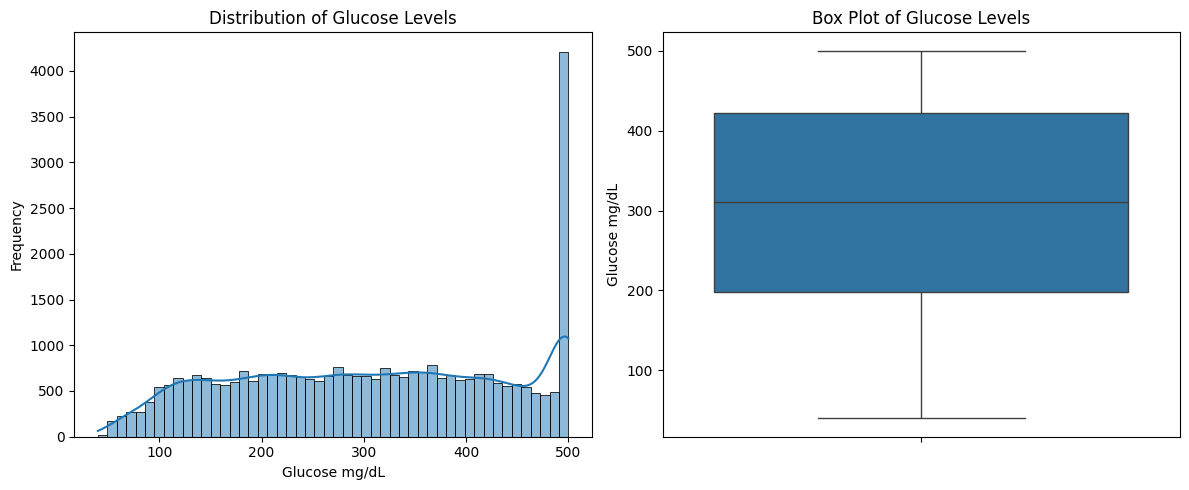

In [49]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(canine_df['glucose'], bins=50, kde=True)
plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose mg/dL')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=canine_df['glucose'])
plt.title('Box Plot of Glucose Levels')
plt.ylabel('Glucose mg/dL')

plt.tight_layout()
plt.show()

## Visualize Canine Glucose Trends Over Time

Plot the 'glucose' values against 'timestamp' for each unique 'file_identifier' to observe individual trends over time. Each dog has its own trend line in a single plot.

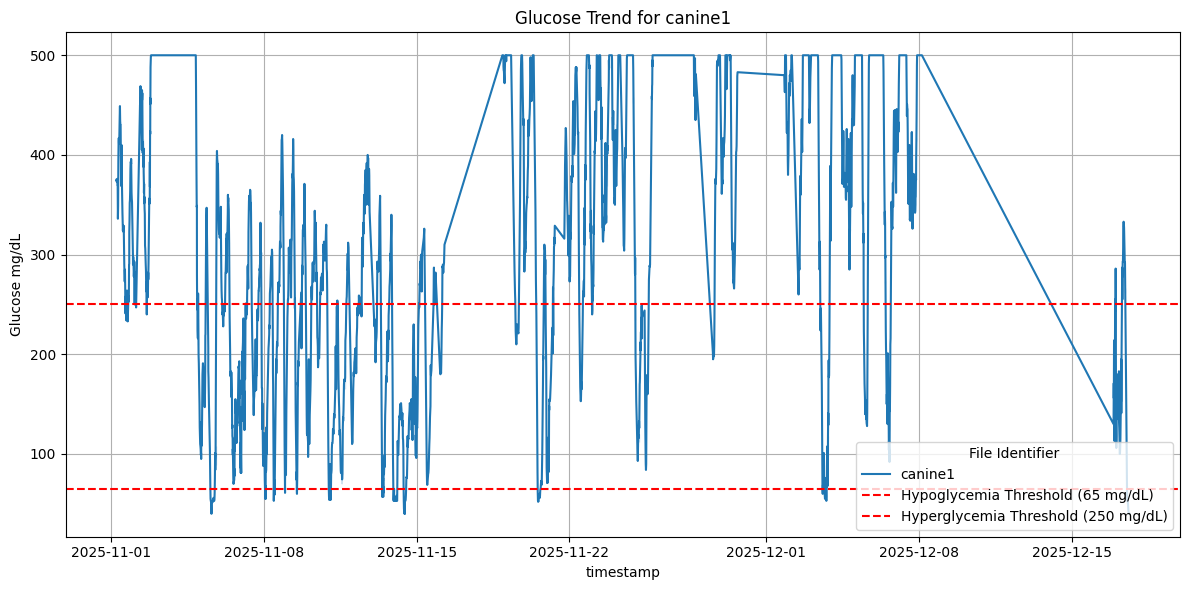

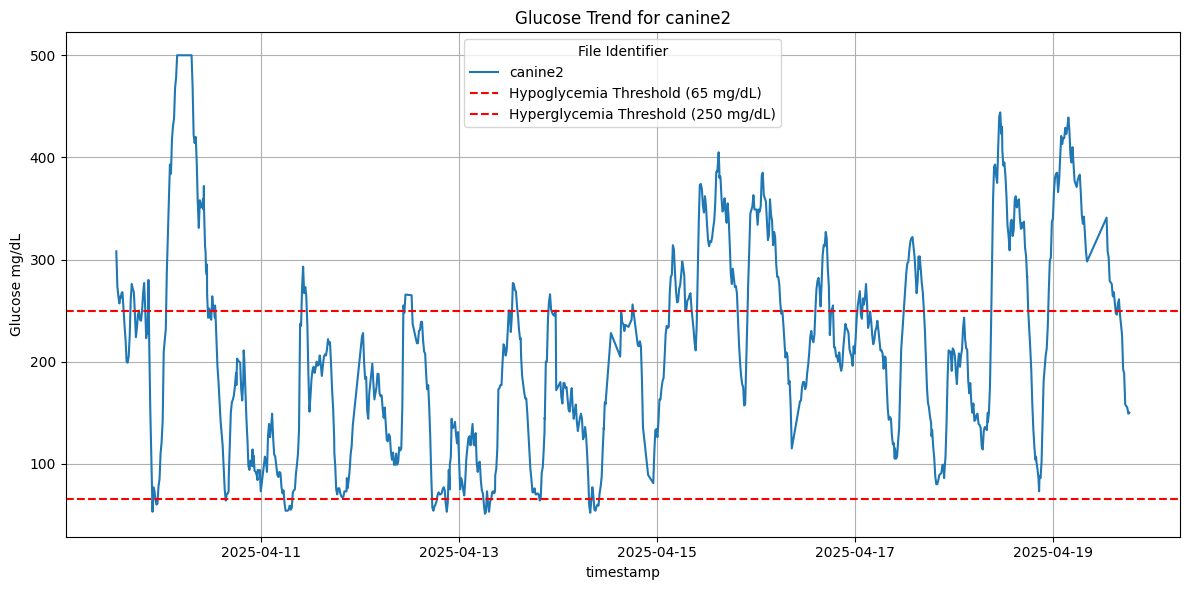

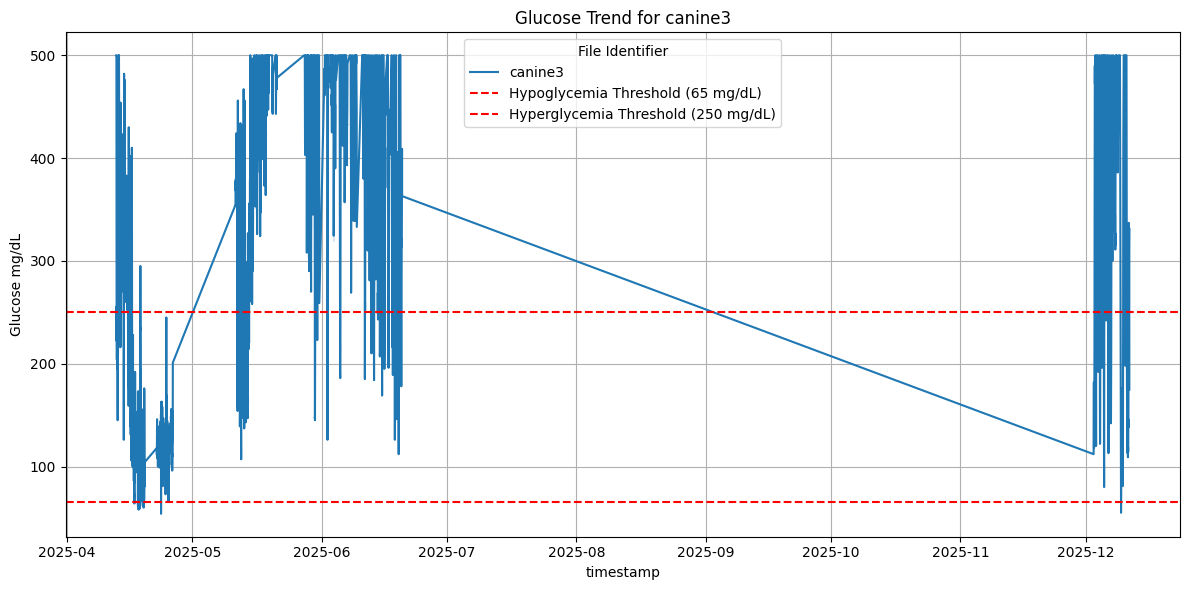

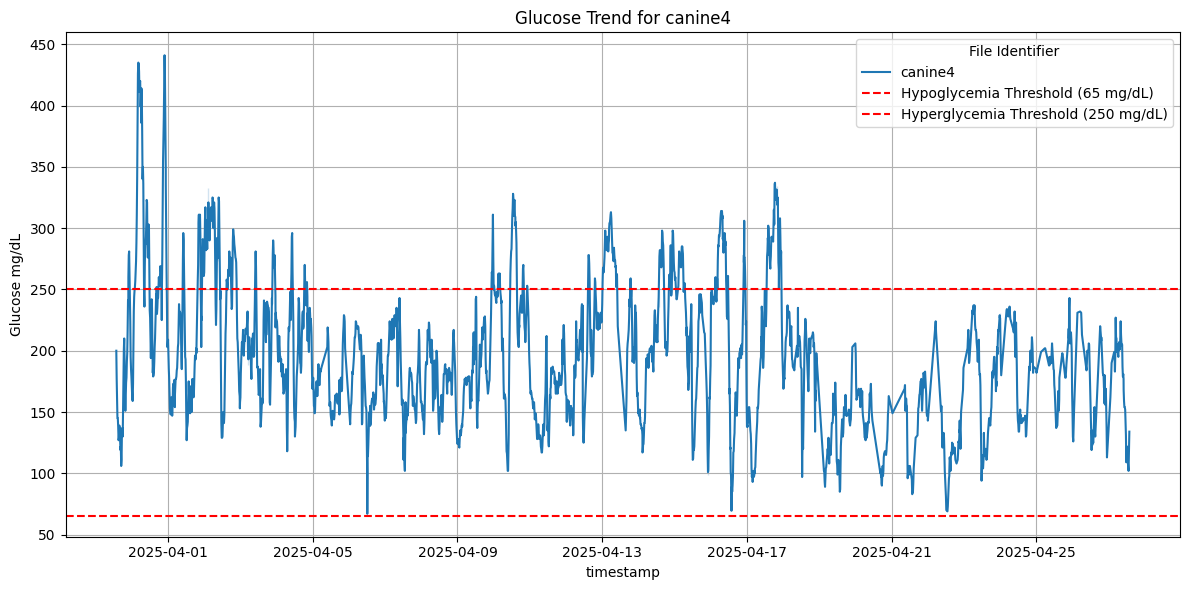

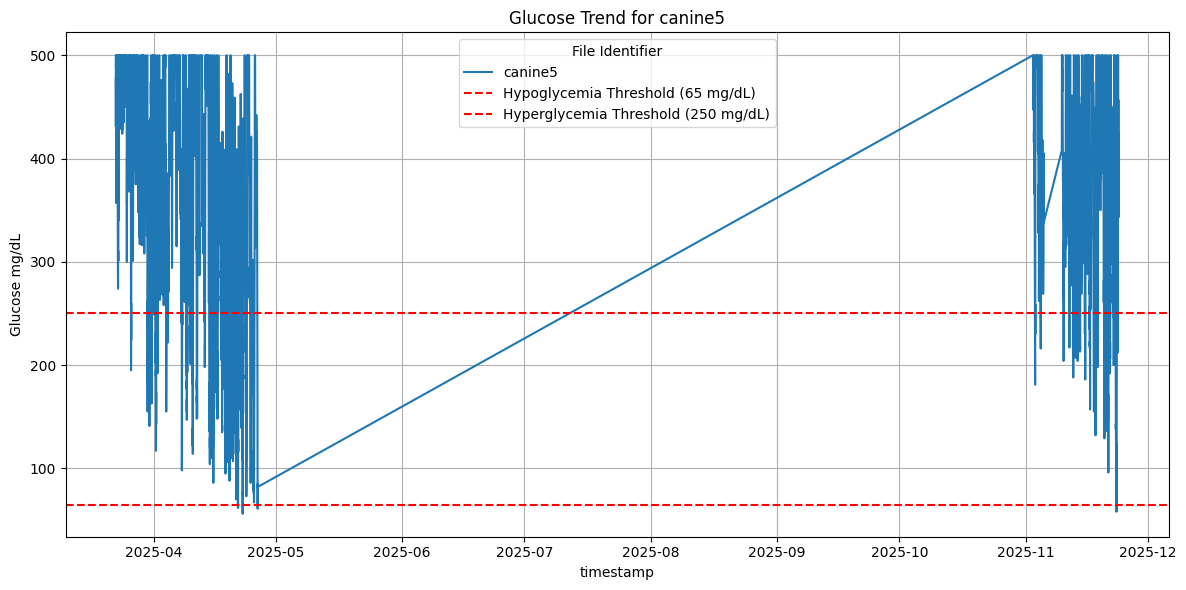

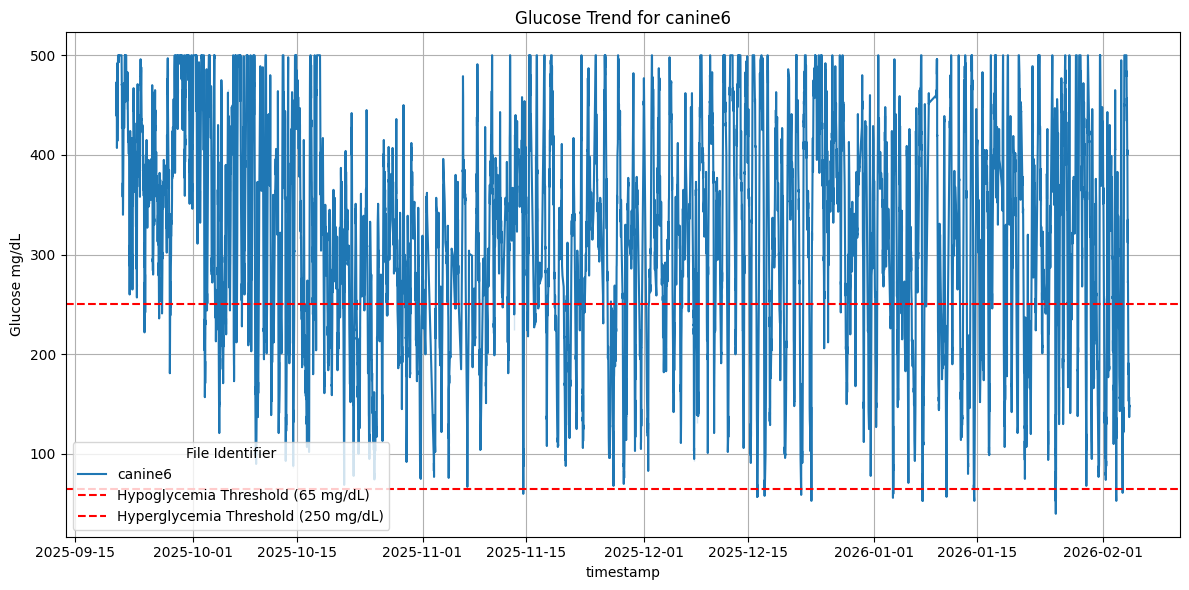

In [50]:

unique_identifiers = canine_df['file_identifier'].unique()

for identifier in unique_identifiers:
    plt.figure(figsize=(12, 6))

    # Filter data for the current identifier
    df_filtered = canine_df[canine_df['file_identifier'] == identifier]

    # Sort by 'timestamp' to ensure chronological order
    df_filtered = df_filtered.sort_values(by='timestamp')

    # Plot glucose trend for the current identifier
    sns.lineplot(data=df_filtered, x='timestamp', y='glucose', label=identifier)

    # Add alarming thresholds for glucose = 65 and glucose = 250
    plt.axhline(y=65, color='red', linestyle='--', label='Hypoglycemia Threshold (65 mg/dL)')
    plt.axhline(y=250, color='red', linestyle='--', label='Hyperglycemia Threshold (250 mg/dL)')

    plt.title(f'Glucose Trend for {identifier}')
    plt.xlabel('timestamp')
    plt.ylabel('Glucose mg/dL')
    plt.legend(title='File Identifier')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Human Data EDA

## Human Data Load

In [51]:
dataset_path = '/content/drive/MyDrive/210 Capstone/datasets'

# Filter files to include only those starting with 'g' and ending with '.csv'
human_found_files = [f for f in os.listdir(dataset_path) if f.startswith('g') and f.endswith('.csv')]

if human_found_files:
    print(f"Files in '{dataset_path}' starting with 'g' and ending with '.csv':")
    for f in human_found_files:
        print(f)
else:
    print("No files found starting with 'g' and ending with '.csv'.")

Files in '/content/drive/MyDrive/210 Capstone/datasets' starting with 'g' and ending with '.csv':
g2_Patient_253_5.csv
g2_Patient_222_3.csv
g1_Patient_15_1.csv
g1_Patient_174_9.csv
g2_Patient_242_8.csv
g2_Patient_271_1.csv
g2_Patient_255_10.csv
g1_Patient_109_7.csv
g3_Patient_288_8.csv
g3_Patient_333_4.csv
g2_Patient_20_9.csv
g1_Patient_133_8.csv
g2_Patient_213_2.csv
g1_Patient_151_6.csv
g1_Patient_117_10.csv
g3_Patient_308_3.csv
g1_Patient_131_2.csv
g2_Patient_265_7.csv
g1_Patient_180_4.csv
g1_Patient_164_5.csv
g2_Patient_24_6.csv
g3_Patient_320_1.csv
g3_Patient_287_9.csv
g1_Patient_173_3.csv
g2_Patient_26_4.csv
g5_Patient_67_5.csv
g5_Patient_53_8.csv
g3_Patient_368_6.csv
g4_Patient_399_4.csv
g4_Patient_402_7.csv
g4_Patient_461_3.csv
g3_Patient_344_7.csv
g5_Patient_76_9.csv
g3_Patient_34_10.csv
g4_Patient_428_1.csv
g5_Patient_484_2.csv
g4_Patient_397_2.csv
g3_Patient_339_2.csv
g4_Patient_400_8.csv
g5_Patient_489_1.csv
g4_Patient_429_9.csv
g5_Patient_7_3.csv
g5_Patient_70_6.csv
g5_Pati

In [52]:
human_dfs = []

for filename in human_found_files:
    full_file_path = os.path.join(dataset_path, filename)

    # Extract identifier to be 'Patient_YY' from 'gX_Patient_YY_Z.csv'
    # The format is 'gX_Patient_YY_Z.csv', so we split by '_' and take the second and third parts.
    parts = filename.split('_')
    identifier = f"{parts[1]}_{parts[2]}"

    # Read the file into a DataFrame
    df = pd.read_csv(full_file_path)

    # Add a new column 'file_identifier'
    df['file_identifier'] = identifier

    # Append the processed DataFrame to the list
    human_dfs.append(df)

# Combine all DataFrames into a single human_combined_df
human_combined_df = pd.concat(human_dfs, ignore_index=True)

print(f"Successfully processed {len(human_dfs)} human files and combined them into 'human_combined_df'.")
print("Shape of the human_combined_df:")
print(human_combined_df.shape)
print("First 5 rows of the human_combined_df:")
display(human_combined_df.head())

Successfully processed 50 human files and combined them into 'human_combined_df'.
Shape of the human_combined_df:
(1202213, 3)
First 5 rows of the human_combined_df:


,DeviceDtTm,Glucose,file_identifier
0,2001-02-21 08:40:00.000000,126,Patient_253
1,2001-02-21 08:35:00.000000,126,Patient_253
2,2001-02-21 08:30:00.000000,126,Patient_253
3,2001-02-21 08:25:00.000000,128,Patient_253
4,2001-02-21 08:20:00.000000,128,Patient_253


In [53]:
# Format Columns and Create human_df
human_df = human_combined_df.rename(columns={'DeviceDtTm': 'timestamp', 'Glucose': 'glucose'})


human_df.loc[:, 'timestamp'] = pd.to_datetime(human_df['timestamp'], format='mixed')
human_df['hypoglycemia'] = human_df['glucose'] < 70
human_df['hyperglycemia'] = human_df['glucose'] > 180

# Remove rows where human glucose > 500 (due to device error)
human_df = human_df[human_df['glucose'] <= 500]

display(human_df.head())
print(f"Shape of human_df: {human_df.shape}")

,timestamp,glucose,file_identifier,hypoglycemia,hyperglycemia
0,2001-02-21 08:40:00,126,Patient_253,False,False
1,2001-02-21 08:35:00,126,Patient_253,False,False
2,2001-02-21 08:30:00,126,Patient_253,False,False
3,2001-02-21 08:25:00,128,Patient_253,False,False
4,2001-02-21 08:20:00,128,Patient_253,False,False


Shape of human_df: (1201951, 5)


In [54]:
def categorize_glucose_human(glucose):
    if glucose < 70:
        return 'Hypoglycemia'
    elif glucose > 180:
        return 'Hyperglycemia'
    else:
        return 'Normal'

human_df['glucose_category'] = human_df['glucose'].apply(categorize_glucose_human)

# Reorder columns as requested
human_df = human_df[['file_identifier', 'timestamp', 'glucose', 'hypoglycemia', 'hyperglycemia', 'glucose_category']]

display(human_df.head())
print(f"Shape of human_df: {human_df.shape}")

,file_identifier,timestamp,glucose,hypoglycemia,hyperglycemia,glucose_category
0,Patient_253,2001-02-21 08:40:00,126,False,False,Normal
1,Patient_253,2001-02-21 08:35:00,126,False,False,Normal
2,Patient_253,2001-02-21 08:30:00,126,False,False,Normal
3,Patient_253,2001-02-21 08:25:00,128,False,False,Normal
4,Patient_253,2001-02-21 08:20:00,128,False,False,Normal


Shape of human_df: (1201951, 6)


## Descriptive Statistics for Human Glucose

In [55]:
# Data Sanity Check
print("DataFrame Info:")
human_df.info()

print("\nMissing values per column:")
print(human_df.isnull().sum())

print(human_df['glucose'].describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1201951 entries, 0 to 1202212
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   file_identifier   1201951 non-null  object
 1   timestamp         1201951 non-null  object
 2   glucose           1201951 non-null  int64 
 3   hypoglycemia      1201951 non-null  bool  
 4   hyperglycemia     1201951 non-null  bool  
 5   glucose_category  1201951 non-null  object
dtypes: bool(2), int64(1), object(3)
memory usage: 48.1+ MB

Missing values per column:
file_identifier     0
timestamp           0
glucose             0
hypoglycemia        0
hyperglycemia       0
glucose_category    0
dtype: int64
count    1.201951e+06
mean     1.649295e+02
std      6.700975e+01
min      1.600000e+01
25%      1.160000e+02
50%      1.540000e+02
75%      2.040000e+02
max      5.000000e+02
Name: glucose, dtype: float64


## Visualize Human Glucose Distribution


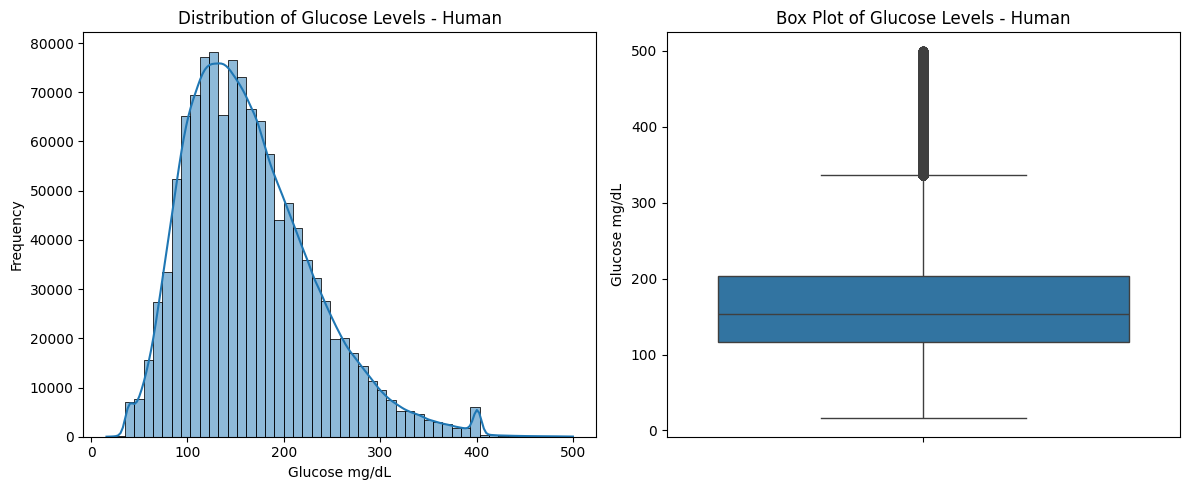

In [56]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(human_df['glucose'], bins=50, kde=True)
plt.title('Distribution of Glucose Levels - Human')
plt.xlabel('Glucose mg/dL')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=human_df['glucose'])
plt.title('Box Plot of Glucose Levels - Human')
plt.ylabel('Glucose mg/dL')

plt.tight_layout()
plt.show()

## Analyze Human Hypoglycemia and Hyperglycemia Events

In [57]:
category_counts_human = human_df.groupby(['file_identifier', 'glucose_category']).size().unstack(fill_value=0)
category_counts_human['Total'] = category_counts_human.sum(axis=1)

category_percentages_human = category_counts_human.iloc[:, :-1].div(category_counts_human['Total'], axis=0) * 100
category_percentages_human = category_percentages_human.round(2)

category_percentages_human_renamed = category_percentages_human.add_suffix('_Percent')
combined_table_human = pd.concat([category_counts_human, category_percentages_human_renamed], axis=1)

display(combined_table_human)


glucose_category,Hyperglycemia,Hypoglycemia,Normal,Total,Hyperglycemia_Percent,Hypoglycemia_Percent,Normal_Percent
file_identifier,,,,,,,
Patient_109,7094,61,10622,17777,39.91,0.34,59.75
Patient_117,8729,14,8298,17041,51.22,0.08,48.69
Patient_131,10286,3652,11175,25113,40.96,14.54,44.50
Patient_133,8967,535,28891,38393,23.36,1.39,75.25
Patient_15,8283,932,17314,26529,31.22,3.51,65.26
Patient_151,3822,981,21411,26214,14.58,3.74,81.68
Patient_164,2269,4212,16948,23429,9.68,17.98,72.34
Patient_173,5000,881,8236,14117,35.42,6.24,58.34
Patient_174,8034,563,25455,34052,23.59,1.65,74.75


# ROC Anaysis

## ROC Definition

ROC (Rate of Change of glucose):
In CGM time series, ROC answers one question: **How fast is glucose changing right now?**


**Mathematical definition:** For two consecutive readings,






$$ROC_t = \frac{G_t - G_{t-1}}{\Delta t_{\text{minutes}}}$$




*   𝐺𝑡: glucose at time 𝑡 (mg/dL)
*   Δ𝑡: time gap between readings (in minutes)

*   Units: mg/dL per minute


**Interpretation:**


*   ROC < 0 → glucose is dropping
*   ROC > 0 → glucose is rising


*   Large |ROC| → fast change (dangerous for hypoglycemia)

In [58]:
# Function for adding ROC into dfs

def add_roc(df):
    d = df.copy()

    # types + sort
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d["glucose"] = pd.to_numeric(d["glucose"], errors="coerce")
    d = d.dropna(subset=["file_identifier", "timestamp"]).sort_values(
        ["file_identifier", "timestamp"]
    )

    # dt (minutes) per subject
    d["dt_min"] = (
        d.groupby("file_identifier")["timestamp"]
         .diff()
         .dt.total_seconds() / 60
    )

    # ROC (mg/dL per minute) per subject
    d["roc"] = d.groupby("file_identifier")["glucose"].diff() / d["dt_min"]
    d["roc"] = d["roc"].replace([np.inf, -np.inf], np.nan)

    return d


In [59]:
canine_df = add_roc(canine_df)
human_df  = add_roc(human_df)

In [60]:
# ROC Summary

def roc_quick_summary(d, name):
    print(f"\n=== {name} ===")
    print("dt_min (minutes) summary:")
    print(d["dt_min"].dropna().describe(percentiles=[.01, .05, .5, .95, .99]))

    roc = d["roc"].dropna()
    print("\nroc (mg/dL/min) summary:")
    print(roc.describe(percentiles=[.01, .05, .5, .95, .99]))

    print("\n% dt_min <= 0 (duplicates/out-of-order):",
          (d["dt_min"] <= 0).mean() * 100)

roc_quick_summary(canine_df, "CANINE")
roc_quick_summary(human_df, "HUMAN")



=== CANINE ===
dt_min (minutes) summary:
count     32890.000000
mean         31.099270
std        2008.645883
min           0.000000
1%            0.000000
5%            1.000000
50%          15.000000
95%          16.000000
99%          78.110000
max      273825.000000
Name: dt_min, dtype: float64

roc (mg/dL/min) summary:
count    31893.000000
mean         0.045052
std          3.226774
min        -74.000000
1%          -8.000000
5%          -3.250000
50%          0.000000
95%          3.447312
99%          9.500000
max         89.000000
Name: roc, dtype: float64

% dt_min <= 0 (duplicates/out-of-order): 3.030763618677043

=== HUMAN ===
dt_min (minutes) summary:
count    1.201901e+06
mean     1.038584e+01
std      3.172019e+02
min      0.000000e+00
1%       4.999833e+00
5%       5.000000e+00
50%      5.000000e+00
95%      1.005000e+01
99%      1.500017e+01
max      1.397040e+05
Name: dt_min, dtype: float64

roc (mg/dL/min) summary:
count    1.201900e+06
mean    -8.425748e-04
std    

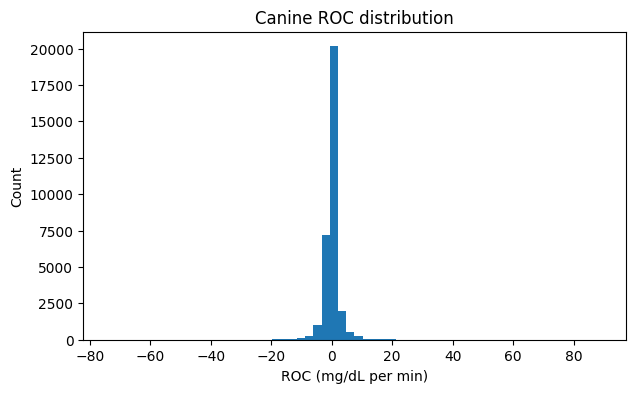

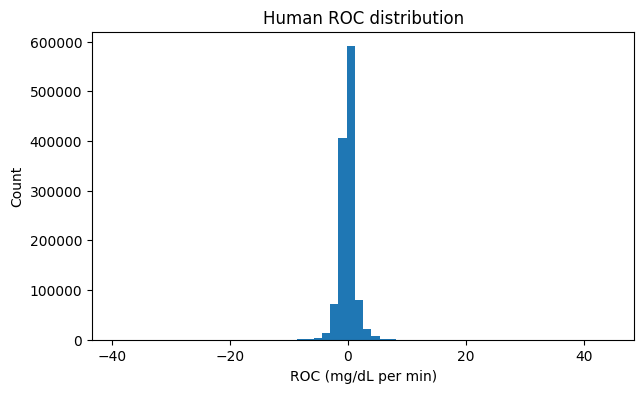

In [61]:

def plot_roc_hist(d, title):
    roc = d["roc"].dropna()
    plt.figure(figsize=(7,4))
    plt.hist(roc, bins=60)
    plt.title(title)
    plt.xlabel("ROC (mg/dL per min)")
    plt.ylabel("Count")
    plt.show()

plot_roc_hist(canine_df, "Canine ROC distribution")
plot_roc_hist(human_df,  "Human ROC distribution")


## ROC-Clean

**Reason:** current canine max gap is enormous; without filtering, the min/max ROC values are not meaningful.

**How:** EDA revealed prolonged data gaps for certain canine subjects (e.g., Canine 5 had no glucose data between May to Nov.). Because ROC and volatility metrics depend on consecutive time intervals, we segmented affected time series into separate continuous sessions (e.g., Canine 5 → Canine 5-1 and Canine 5-2). This prevents long gaps from artificially distorting ROC and rolling variability calculations.

In [62]:
# STEP 1-1: Separate Canine Data - canine5

# isolate canine5
c5 = canine_df[canine_df["file_identifier"] == "canine5"].copy()

# define gap boundaries
gap_start = pd.Timestamp("2025-04-26")
gap_end   = pd.Timestamp("2025-11-01")

# before the gap → canine51
canine51 = c5[c5["timestamp"] < gap_start].copy()
canine51["file_identifier"] = "canine51"

# after the gap → canine52
canine52 = c5[c5["timestamp"] > gap_end].copy()
canine52["file_identifier"] = "canine52"

# everything else (other dogs)
others = canine_df[canine_df["file_identifier"] != "canine5"].copy()

# recombine
canine_df_split = pd.concat([others, canine51, canine52], ignore_index=True)

# sanity check
print(canine_df_split["file_identifier"].value_counts())



file_identifier
canine6     14277
canine3      5973
canine51     4248
canine1      3104
canine4      2470
canine52     1748
canine2      1009
Name: count, dtype: int64


In [63]:
# STEP 1-2: Separate Canine Data - canine3
# Pull canine3
c3 = canine_df_split[canine_df_split["file_identifier"] == "canine3"].copy()

# Define your gap ranges (no data)
gaps = [
    (pd.Timestamp("2025-04-27"), pd.Timestamp("2025-05-10")),
    (pd.Timestamp("2025-05-22"), pd.Timestamp("2025-05-26")),
    (pd.Timestamp("2025-06-02"), pd.Timestamp("2025-12-01")),
]

# Sort gaps just in case
gaps = sorted(gaps, key=lambda x: x[0])

# Build segment boundaries from gaps
# Segments are: (-inf, gap1_start), (gap1_end, gap2_start), (gap2_end, gap3_start), (gap3_end, +inf)
bounds = [
    (pd.Timestamp.min, gaps[0][0]),
    (gaps[0][1], gaps[1][0]),
    (gaps[1][1], gaps[2][0]),
    (gaps[2][1], pd.Timestamp.max),
]

# Create 4 segmented dfs
segments = []
for i, (lo, hi) in enumerate(bounds, start=1):
    seg = c3[(c3["timestamp"] < hi) & (c3["timestamp"] > lo)].copy()
    seg["file_identifier"] = f"canine3{i}"  # canine31..canine34
    segments.append(seg)

canine31, canine32, canine33, canine34 = segments

# Combine back with all other dogs (and exclude original canine3)
others = canine_df_split[canine_df_split["file_identifier"] != "canine3"].copy()
canine_df_split = pd.concat([others, canine31, canine32, canine33, canine34], ignore_index=True)

# Sanity checks
print(canine_df_split["file_identifier"].value_counts().loc[["canine31","canine32","canine33","canine34"]])
print("Original canine3 rows kept?", (canine_df_split["file_identifier"] == "canine3").sum())


file_identifier
canine31    2193
canine32    1106
canine33     538
canine34     625
Name: count, dtype: int64
Original canine3 rows kept? 0



=== CANINE-C ===
dt_min (minutes) summary:
count    31308.000000
mean        14.446499
std         94.501400
min          0.000000
1%           0.000000
5%           1.000000
50%         15.000000
95%         16.000000
99%         76.930000
max      12641.000000
Name: dt_min, dtype: float64

roc (mg/dL/min) summary:
count    30350.000000
mean         0.045975
std          3.271692
min        -74.000000
1%          -8.000000
5%          -3.266667
50%          0.000000
95%          3.500000
99%         10.000000
max         89.000000
Name: roc, dtype: float64

% dt_min <= 0 (duplicates/out-of-order): 3.0589437384251865


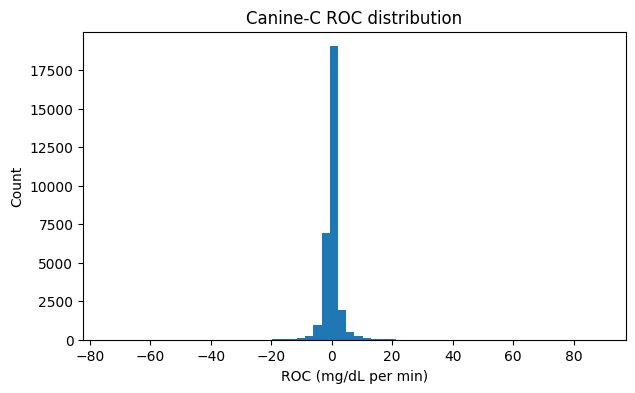

In [64]:
# STEP 2: ROC-Clean Calculation
canine_df_split  = add_roc(canine_df_split)
roc_quick_summary(canine_df_split, "CANINE-C")
plot_roc_hist(canine_df_split,  "Canine-C ROC distribution")

##ROC Comparison Output
We have two clean tables, Both share the same schema:


*   canine_df (dog CGM; typically every 15 mins)
*   human_df (human CGM; typically every 5 mins)


Goal: produce a side-by-side table that compares dynamics-related properties across species in a fair way.

Key idea: even if sampling frequency differs, we can compare fairly by using:

1. Δt-aware ROC (mg/dL per minute)
2. time-based rolling window (e.g., 60 minutes) rather than “rolling N rows”


In [65]:
def compute_metrics(df, label, roll_window="60min", steep_drop=-2.0):

    d = df.dropna(subset=["file_identifier", "timestamp"]).sort_values(["file_identifier", "timestamp"])

    dt = d["dt_min"].dropna()
    dt_pos = dt[dt > 0]                 # ignore duplicates/out-of-order for interval stats
    g = d["glucose"].dropna()
    r = d["roc"].replace([np.inf, -np.inf], np.nan).dropna()

    # rolling volatility (time-based), computed per subject then pooled
    roll_std_all, roll_cv_all = [], []
    for _, sub in d.dropna(subset=["glucose"]).groupby("file_identifier"):
        sub = sub.set_index("timestamp").sort_index()
        rs = sub["glucose"].rolling(roll_window).std()
        rm = sub["glucose"].rolling(roll_window).mean()
        roll_std_all.append(rs)
        roll_cv_all.append(rs / rm)

    roll_std_all = pd.concat(roll_std_all) if roll_std_all else pd.Series(dtype=float)
    roll_cv_all  = pd.concat(roll_cv_all)  if roll_cv_all  else pd.Series(dtype=float)

    return {
        "dataset": label,

        # coverage
        "n_subjects": d["file_identifier"].nunique(),
        "n_rows": len(d),
        "start": d["timestamp"].min(),
        "end": d["timestamp"].max(),
        "days_span": (d["timestamp"].max() - d["timestamp"].min()).total_seconds() / 86400,

        # sampling interval (from dt_min)
        "dt_median_min": float(np.nanmedian(dt_pos)) if len(dt_pos) else np.nan,
        "dt_p95_min": float(np.nanpercentile(dt_pos, 95)) if len(dt_pos) else np.nan,
        "dt_max_gap_min": float(np.nanmax(dt_pos)) if len(dt_pos) else np.nan,
        "dt_duplicates_pct": float((dt <= 0).mean() * 100) if len(dt) else np.nan,

        # glucose distribution
        "glucose_min": float(np.nanmin(g)) if len(g) else np.nan,
        "glucose_p5": float(np.nanpercentile(g, 5)) if len(g) else np.nan,
        "glucose_median": float(np.nanmedian(g)) if len(g) else np.nan,
        "glucose_mean": float(np.nanmean(g)) if len(g) else np.nan,
        "glucose_p95": float(np.nanpercentile(g, 95)) if len(g) else np.nan,
        "glucose_max": float(np.nanmax(g)) if len(g) else np.nan,

        # ROC dynamics (from existing roc)
        "roc_p5": float(np.nanpercentile(r, 5)) if len(r) else np.nan,
        "roc_median": float(np.nanmedian(r)) if len(r) else np.nan,
        "roc_p95": float(np.nanpercentile(r, 95)) if len(r) else np.nan,
        "steep_drop_pct": float((r <= steep_drop).mean() * 100) if len(r) else np.nan,

        # rolling volatility
        "roll_std_median": float(np.nanmedian(roll_std_all)) if len(roll_std_all) else np.nan,
        "roll_std_p95": float(np.nanpercentile(roll_std_all.dropna(), 95)) if roll_std_all.notna().any() else np.nan,
        "roll_cv_median": float(np.nanmedian(roll_cv_all)) if len(roll_cv_all) else np.nan,
        "roll_cv_p95": float(np.nanpercentile(roll_cv_all.dropna(), 95)) if roll_cv_all.notna().any() else np.nan,
    }


####Metric Definitions for ROC Comparison Table

**Dataset & Coverage**

dataset:
    Identifier for the dataset being summarized (e.g., canine, canine_clean, human).

n_subjects:
    Number of unique individuals represented in the dataset, defined by distinct
    file_identifier values.

n_rows:
    Total number of glucose records included in the dataset.

start / end:
    Earliest and latest timestamps in the dataset.

days_span:
    Total time span covered by the dataset in days.

**Sampling Interval Metrics (dt_min)**

dt_median_min:
    Median time difference (minutes) between consecutive glucose readings.

dt_p95_min:
    95th percentile of time differences, capturing typical larger gaps.

dt_max_gap_min:
    Maximum observed time gap between consecutive readings.

dt_duplicates_pct:
    Percentage of intervals with dt_min ≤ 0, indicating duplicate or out-of-order
    timestamps that may distort ROC.

**Glucose Distribution Metrics**

glucose_min / glucose_max:
    Minimum and maximum observed glucose values (mg/dL).

glucose_p5 / glucose_p95:
    5th and 95th percentile glucose values, representing typical low and high exposure.

glucose_median / glucose_mean:
    Median and mean glucose values.

**Rate of Change (ROC) Metrics**

ROC is defined as:
    (glucose_t - glucose_{t-1}) / Δt_minutes

roc_p5:
    5th percentile of ROC, representing typical rapid glucose declines relevant to
    early hypoglycemia risk.

roc_median:
    Median ROC, typically near zero.

roc_p95:
    95th percentile of ROC, capturing rapid glucose increases.

steep_drop_pct:
    Percentage of ROC values below a predefined threshold (e.g., ROC ≤ −2 mg/dL/min).

**Rolling Volatility Metrics (Time-Based Window)**

roll_std_median / roll_std_p95:
    Median and 95th percentile of rolling glucose standard deviation, measuring
    short-term absolute variability.

roll_cv_median / roll_cv_p95:
    Median and 95th percentile of rolling coefficient of variation (CV = std / mean),
    measuring relative glucose variability normalized by glucose level.
"""


In [66]:
canine_metrics   = compute_metrics(canine_df,       "canine",   roll_window="60min", steep_drop=-2.0)
canine_c_metrics = compute_metrics(canine_df_split, "canine_c", roll_window="60min", steep_drop=-2.0)
human_metrics    = compute_metrics(human_df,        "human",    roll_window="60min", steep_drop=-2.0)

comparison = pd.DataFrame([canine_metrics, canine_c_metrics, human_metrics])

cols_order = [
    "dataset","n_subjects","n_rows","start","end","days_span",
    "dt_median_min","dt_p95_min","dt_max_gap_min","dt_duplicates_pct",
    "glucose_min","glucose_p5","glucose_median","glucose_mean","glucose_p95","glucose_max",
    "roc_p5","roc_median","roc_p95","steep_drop_pct",
    "roll_std_median","roll_std_p95","roll_cv_median","roll_cv_p95"
]
comparison = comparison[cols_order]
comparison_T = comparison.set_index("dataset").T
comparison_T


dataset,canine,canine_c,human
n_subjects,6,10,50
n_rows,32896,31318,1201951
start,2025-03-22 17:43:00,2025-03-22 17:43:00,2000-07-23 00:00:00
end,2026-02-04 12:57:00,2026-02-04 12:57:00,2001-12-19 06:14:46.010000
days_span,318.801389,318.801389,514.260255
dt_median_min,15.0,15.0,5.0
dt_p95_min,16.0,16.0,10.05
dt_max_gap_min,273825.0,12641.0,139704.0
dt_duplicates_pct,3.031317,3.059921,0.000083
glucose_min,40.0,40.0,16.0


# When Happen?

Which time we see most hypo/hyper?

In [67]:
def time_in_state_by_hour(df, label):
    """
    Computes % of time in hypoglycemia / hyperglycemia by hour of day.
    Uses dt_min as weights (minutes between consecutive readings).
    """

    d = df.copy()

    # 1) Ensure datetime + sort so dt is correct
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d = d.dropna(subset=["file_identifier", "timestamp"]).sort_values(["file_identifier", "timestamp"])

    # 2) Ensure boolean flags (in case they're strings)
    for col in ["hypoglycemia", "hyperglycemia"]:
        if d[col].dtype == "object":
            d[col] = d[col].astype(str).str.lower().map({"true": True, "false": False})

    # 3) Compute dt_min if not already present
    if "dt_min" not in d.columns:
        d["dt_min"] = d.groupby("file_identifier")["timestamp"].diff().dt.total_seconds() / 60.0

    # 4) Clean dt: first row per subject is NaN -> 0, negatives -> 0
    d["dt_min"] = d["dt_min"].fillna(0)
    d.loc[d["dt_min"] < 0, "dt_min"] = 0

    # 5) Hour of day (0-23)
    d["hour"] = d["timestamp"].dt.hour

    # 6) Weighted minutes in state per hour
    hourly = (
        d.groupby("hour")
         .apply(lambda x: pd.Series({
             "total_minutes": x["dt_min"].sum(),
             "hypo_minutes": (x["dt_min"] * (x["hypoglycemia"] == True)).sum(),
             "hyper_minutes": (x["dt_min"] * (x["hyperglycemia"] == True)).sum(),
         }))
         .reset_index()
         .sort_values("hour")
    )

    # 7) Convert to % of time
    hourly["hypo_time_pct"] = np.where(
        hourly["total_minutes"] > 0,
        100 * hourly["hypo_minutes"] / hourly["total_minutes"],
        np.nan
    )
    hourly["hyper_time_pct"] = np.where(
        hourly["total_minutes"] > 0,
        100 * hourly["hyper_minutes"] / hourly["total_minutes"],
        np.nan
    )

    # 8) Print peak hours (optional)
    if hourly["hypo_time_pct"].notna().any():
        peak_hypo = int(hourly.loc[hourly["hypo_time_pct"].idxmax(), "hour"])
    else:
        peak_hypo = None

    if hourly["hyper_time_pct"].notna().any():
        peak_hyper = int(hourly.loc[hourly["hyper_time_pct"].idxmax(), "hour"])
    else:
        peak_hyper = None

    print(f"\n=== {label}: % time in hypo/hyper by hour ===")
    print(hourly[["hour", "total_minutes", "hypo_time_pct", "hyper_time_pct"]])
    print(f"Peak hypo hour: {peak_hypo} | Peak hyper hour: {peak_hyper}")

    return hourly



=== HUMAN: % time in hypo/hyper by hour ===
    hour  total_minutes  hypo_time_pct  hyper_time_pct
0      0  367556.166333       3.311131       39.266539
1      1  363072.394500       3.585227       38.173283
2      2  345985.186667       7.234370       37.489975
3      3  340410.182000       4.262591       42.241190
4      4  315891.299333       4.302368       36.170742
5      5  373895.561500       4.362469       31.226448
6      6  454439.702333       3.124004       34.152012
7      7  706093.686833       3.402191       37.481158
8      8  510661.353833       5.982259       37.791018
9      9  683732.544167       7.892506       37.098910
10    10  570018.118667       6.367639       33.688087
11    11  629805.214667       5.380703       25.581655
12    12  719209.780833       2.919918       31.511862
13    13  596234.522833       2.170117       51.169622
14    14  455313.444667       2.358957       38.311293
15    15  451886.178000       2.642395       35.128238
16    16  529729.335

/tmp/ipython-input-156145993.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipython-input-156145993.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


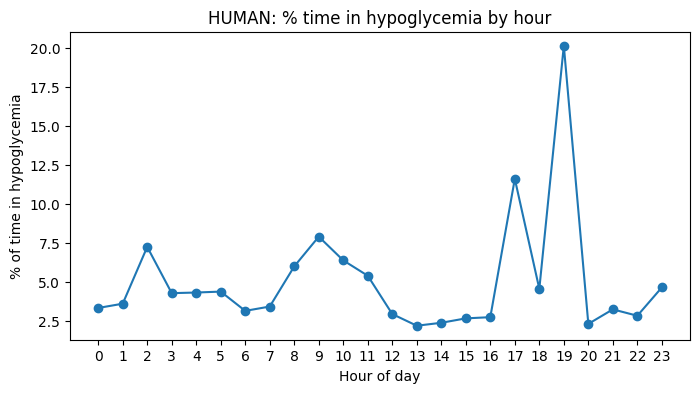

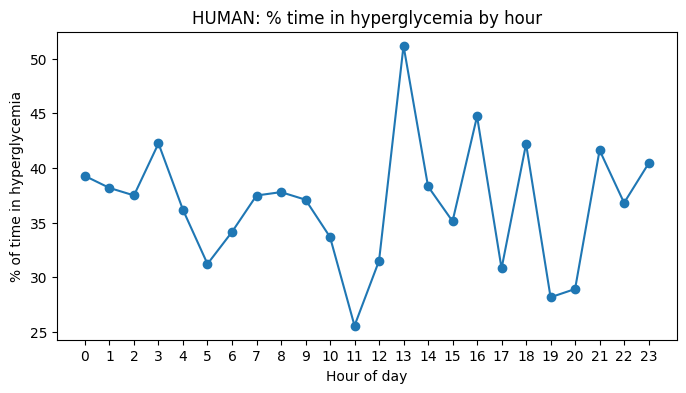

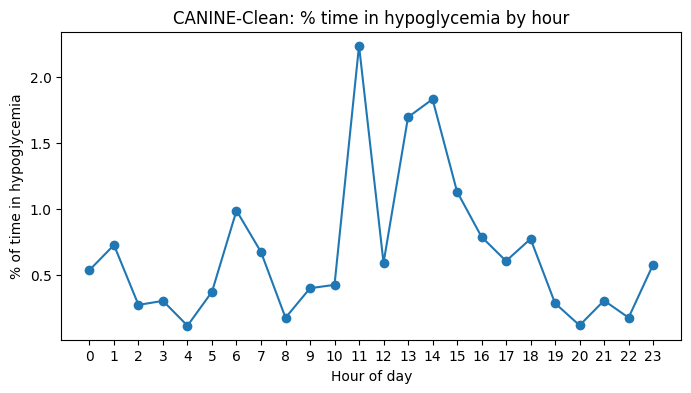

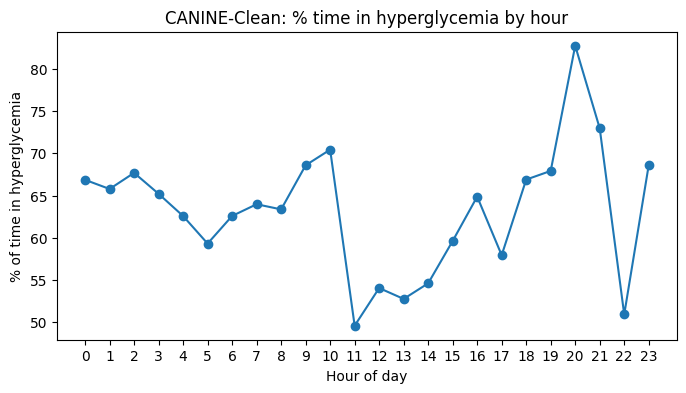

In [68]:
# --- Run for both datasets ---
human_hourly_time  = time_in_state_by_hour(human_df, "HUMAN")
canine_hourly_time = time_in_state_by_hour(canine_df_split, "CANINE-Clean")


# --- Plots ---
plt.figure(figsize=(8,4))
plt.plot(human_hourly_time["hour"], human_hourly_time["hypo_time_pct"], marker="o")
plt.title("HUMAN: % time in hypoglycemia by hour")
plt.xlabel("Hour of day")
plt.ylabel("% of time in hypoglycemia")
plt.xticks(range(0,24))
plt.show()

plt.figure(figsize=(8,4))
plt.plot(human_hourly_time["hour"], human_hourly_time["hyper_time_pct"], marker="o")
plt.title("HUMAN: % time in hyperglycemia by hour")
plt.xlabel("Hour of day")
plt.ylabel("% of time in hyperglycemia")
plt.xticks(range(0,24))
plt.show()

plt.figure(figsize=(8,4))
plt.plot(canine_hourly_time["hour"], canine_hourly_time["hypo_time_pct"], marker="o")
plt.title("CANINE-Clean: % time in hypoglycemia by hour")
plt.xlabel("Hour of day")
plt.ylabel("% of time in hypoglycemia")
plt.xticks(range(0,24))
plt.show()

plt.figure(figsize=(8,4))
plt.plot(canine_hourly_time["hour"], canine_hourly_time["hyper_time_pct"], marker="o")
plt.title("CANINE-Clean: % time in hyperglycemia by hour")
plt.xlabel("Hour of day")
plt.ylabel("% of time in hyperglycemia")
plt.xticks(range(0,24))
plt.show()


# Final DFs

In [69]:
# Add column "safe" : True --> Normal; False --> Hyper or Hypo
human_df["safe"] = human_df["glucose_category"] == "Normal"
canine_df["safe"] = canine_df["glucose_category"] == "Normal"
canine_df_split["safe"] = canine_df_split["glucose_category"] == "Normal"


In [70]:
display(human_df.head())
display(canine_df.head())
display(canine_df_split.head())

,file_identifier,timestamp,glucose,hypoglycemia,hyperglycemia,glucose_category,dt_min,roc,safe
142125,Patient_109,2001-04-27 00:00:25,179,False,False,Normal,NaN,NaN,True
142126,Patient_109,2001-04-27 00:10:31,189,False,True,Hyperglycemia,10.100000,0.990099,False
142127,Patient_109,2001-04-27 00:20:35,191,False,True,Hyperglycemia,10.066667,0.198675,False
142128,Patient_109,2001-04-27 00:30:34,193,False,True,Hyperglycemia,9.983333,0.200334,False
142129,Patient_109,2001-04-27 00:40:28,196,False,True,Hyperglycemia,9.900000,0.303030,False


,file_identifier,timestamp,glucose,hypoglycemia,hyperglycemia,glucose_category,dt_min,roc,safe
2251,canine1,2025-11-01 05:51:00,375.0,False,True,Hyperglycemia,NaN,NaN,False
2252,canine1,2025-11-01 06:06:00,375.0,False,True,Hyperglycemia,15.0,0.000000,False
2253,canine1,2025-11-01 06:21:00,373.0,False,True,Hyperglycemia,15.0,-0.133333,False
2254,canine1,2025-11-01 06:36:00,375.0,False,True,Hyperglycemia,15.0,0.133333,False
2255,canine1,2025-11-01 06:51:00,376.0,False,True,Hyperglycemia,15.0,0.066667,False


,file_identifier,timestamp,glucose,hypoglycemia,hyperglycemia,glucose_category,dt_min,roc,safe
0,canine1,2025-11-01 05:51:00,375.0,False,True,Hyperglycemia,NaN,NaN,False
1,canine1,2025-11-01 06:06:00,375.0,False,True,Hyperglycemia,15.0,0.000000,False
2,canine1,2025-11-01 06:21:00,373.0,False,True,Hyperglycemia,15.0,-0.133333,False
3,canine1,2025-11-01 06:36:00,375.0,False,True,Hyperglycemia,15.0,0.133333,False
4,canine1,2025-11-01 06:51:00,376.0,False,True,Hyperglycemia,15.0,0.066667,False


In [71]:
# Export final data into csv
# target directory
out_dir = "/content/drive/MyDrive/210 Capstone/final_data"

# export dataframes
human_df.to_csv(os.path.join(out_dir, "human_df.csv"), index=False)
canine_df.to_csv(os.path.join(out_dir, "canine_df.csv"), index=False)
canine_df_split.to_csv(os.path.join(out_dir, "canine_df_split.csv"), index=False)

print("Files exported to:", out_dir)


Files exported to: /content/drive/MyDrive/210 Capstone/final_data


In [72]:
# Export final data into pkl

out_dir = "/content/drive/MyDrive/210 Capstone/final_data"
os.makedirs(out_dir, exist_ok=True)

human_df.to_pickle(os.path.join(out_dir, "human_df.pkl"))
canine_df.to_pickle(os.path.join(out_dir, "canine_df.pkl"))
canine_df_split.to_pickle(os.path.join(out_dir, "canine_df_split.pkl"))

print("PKL files saved to:", out_dir)


PKL files saved to: /content/drive/MyDrive/210 Capstone/final_data
